In [68]:
from ucimlrepo import fetch_ucirepo 
  
iris = fetch_ucirepo(id=53) 
  
features = iris.data.features 
targets = iris.data.targets 

In [ ]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

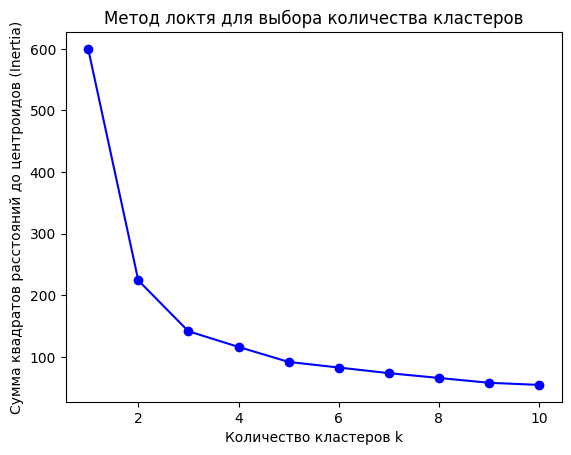

In [ ]:
scaler = StandardScaler()
#features = scaler.fit_transform(features)

inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)


plt.plot(K, inertia, 'bo-')
plt.xlabel('Количество кластеров k')
plt.ylabel('Сумма квадратов расстояний до центроидов (Inertia)')
plt.title('Метод локтя для выбора количества кластеров')    
plt.show()

In [87]:
def plotClusters(cluster_type, values, title, ix):
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, ix)
    plt.scatter(values[:, 0], values[:, 1], c=cluster_type, cmap='viridis')
    plt.title(title)

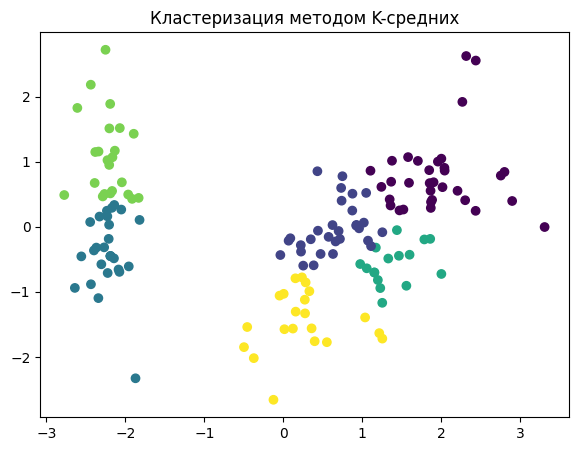

In [200]:
from sklearn.decomposition import PCA
kmeans = KMeans(n_clusters=6, random_state=420, init='random')
clusters_kmeans = kmeans.fit_predict(features)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(features)
plotClusters(clusters_kmeans, X_pca, 'Кластеризация методом K-средних', 1)


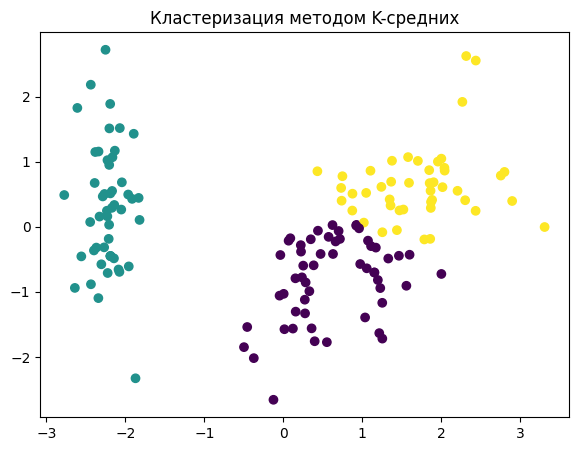

In [223]:
kmeans = KMeans(n_clusters=3)
clusters_kmeans = kmeans.fit_predict(features)
plotClusters(clusters_kmeans, X_pca, 'Кластеризация методом K-средних', 1)

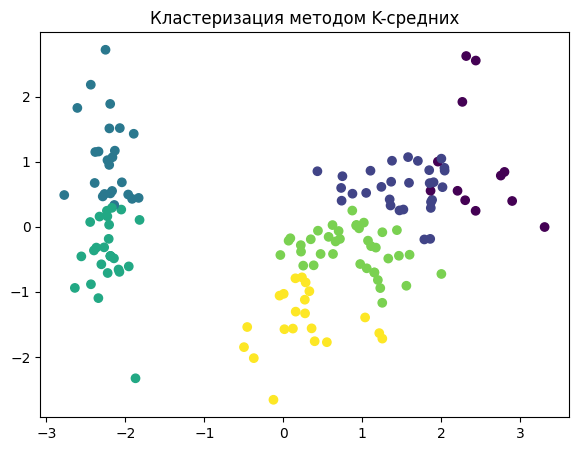

In [222]:
kmeans = KMeans(n_clusters=6, max_iter=1000, init='random', n_init=1000)
clusters_kmeans = kmeans.fit_predict(features)
plotClusters(clusters_kmeans, X_pca, 'Кластеризация методом K-средних', 1)

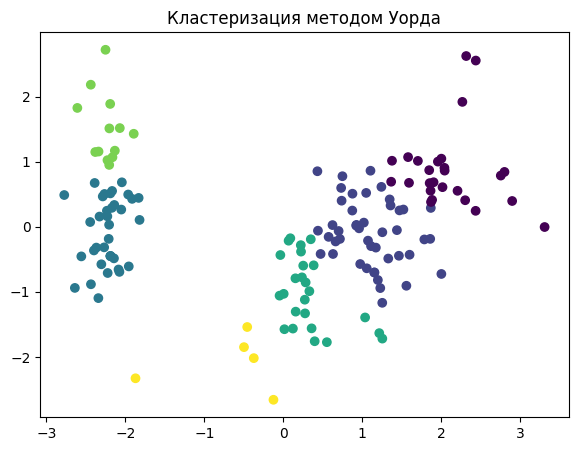

In [107]:
ward = AgglomerativeClustering(n_clusters=6, linkage='ward')
clusters_ward = ward.fit_predict(features)
plotClusters(clusters_ward, X_pca, 'Кластеризация методом Уорда', 2)

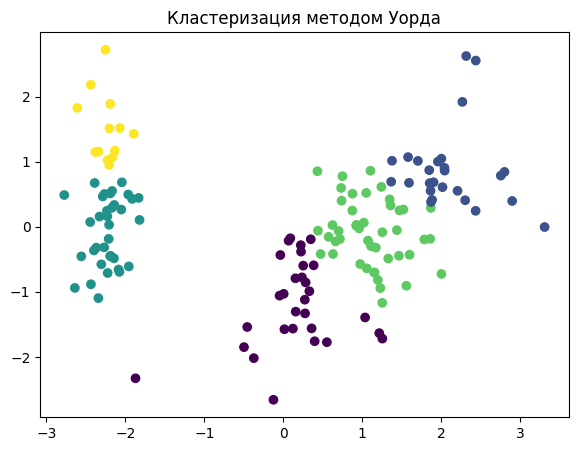

In [190]:
ward = AgglomerativeClustering(n_clusters=None, linkage='ward', distance_threshold=6)
clusters_ward = ward.fit_predict(features)
plotClusters(clusters_ward, X_pca, 'Кластеризация методом Уорда', 2)

In [263]:
from sklearn.calibration import LabelEncoder
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score

label_encoder = LabelEncoder()
targets = label_encoder.fit_transform(targets)

kmeans = KMeans(n_clusters=3, init="random", random_state=11111)
clusters_kmeans = kmeans.fit_predict(features)

print("Метрики для k-средних:")
print("Adjusted Rand Index (ARI):", adjusted_rand_score(targets, clusters_kmeans))
print("Normalized Mutual Information (NMI):", normalized_mutual_info_score(targets, clusters_kmeans))
print("Homogeneity:", homogeneity_score(targets, clusters_kmeans))
print("Completeness:", completeness_score(targets, clusters_kmeans))
print("V-measure:", v_measure_score(targets, clusters_kmeans))

Метрики для k-средних:
Adjusted Rand Index (ARI): 0.5923326221845838
Normalized Mutual Information (NMI): 0.6426583176523605
Homogeneity: 0.6412509939057986
Completeness: 0.6440718321615102
V-measure: 0.6426583176523606


In [255]:
kmeans = KMeans(n_clusters=3)
clusters_kmeans = kmeans.fit_predict(features)

print("Метрики для k-средних:")
print("Adjusted Rand Index (ARI):", adjusted_rand_score(targets, clusters_kmeans))
print("Normalized Mutual Information (NMI):", normalized_mutual_info_score(targets, clusters_kmeans))
print("Homogeneity:", homogeneity_score(targets, clusters_kmeans))
print("Completeness:", completeness_score(targets, clusters_kmeans))
print("V-measure:", v_measure_score(targets, clusters_kmeans))

Метрики для k-средних:
Adjusted Rand Index (ARI): 0.645147003482001
Normalized Mutual Information (NMI): 0.6612870494395353
Homogeneity: 0.6604512238620348
Completeness: 0.6621249932344023
V-measure: 0.6612870494395353


In [246]:
ward = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters_ward = ward.fit_predict(features)

print("\nМетрики для метода Уорда:")
print("Adjusted Rand Index (ARI):", adjusted_rand_score(targets, clusters_ward))
print("Normalized Mutual Information (NMI):", normalized_mutual_info_score(targets, clusters_ward))
print("Homogeneity:", homogeneity_score(targets, clusters_ward))
print("Completeness:", completeness_score(targets, clusters_ward))
print("V-measure:", v_measure_score(targets, clusters_ward))


Метрики для метода Уорда:
Adjusted Rand Index (ARI): 0.6153229932145449
Normalized Mutual Information (NMI): 0.6754701853436886
Homogeneity: 0.6578818079976051
Completeness: 0.6940248415952218
V-measure: 0.6754701853436886
